# AquaTrack Notebook Header

- Project: AquaTrack
- Module: Main Biomarker
- Dataset: `aquatrack_labeled.csv`
- Target: `dehydration_risk` (multiclass categorical)
- Purpose: Perform inline EDA and robust preprocessing/modeling for biomarker-based dehydration risk prediction.

In [1]:
## STEP 1: SETUP AND CONSTANTS
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import joblib

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path("..")
DATA_PATH = PROJECT_ROOT / "aquatrack_labeled.csv"
ARTIFACT_DIR = PROJECT_ROOT / "models" / "artifacts"
PLOT_DIR = ARTIFACT_DIR / "plots"

TARGET_COL = "dehydration_risk"
OLD_TARGET_COL = "dehydration_level"
ID_DROP_COLS = ["id", "age", "height", "weight measured using Kern DE 150K2D [kg]"]
LOG1P_COLS = [
    "salivary amylase [units/l]",
    "salivary protein concentration [mg/l]",
    "salivary cortisol [nmol/l]",
    "salivary cortisone [nmol/l]",
]
WEARABLE_SECONDARY_COL_KEYWORDS = ["impedance", "temperature"]
SKEW_THRESHOLD = 1.5
IQR_WINSOR_FACTOR = 3.0
HIGH_CORR_THRESHOLD = 0.85
PAIRPLOT_TOP_K = 8
RANDOM_STATE = 42
TEST_SIZE = 0.2

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)


df = pd.read_csv(DATA_PATH)
if OLD_TARGET_COL in df.columns and TARGET_COL not in df.columns:
    df = df.rename(columns={OLD_TARGET_COL: TARGET_COL})

assert TARGET_COL in df.columns, f"Missing target column: {TARGET_COL}"

In [2]:
## STEP 2: INLINE EDA FUNCTIONS
# inlined from models/eda_tools.py

def high_correlation_pairs(corr: pd.DataFrame, thresh: float = 0.85) -> pd.DataFrame:
    pairs = []
    for i, a in enumerate(corr.columns):
        for b in corr.columns[i + 1:]:
            val = corr.loc[a, b]
            if np.isfinite(val) and abs(val) >= thresh:
                pairs.append((a, b, float(val)))
    out = pd.DataFrame(pairs, columns=["feature_a", "feature_b", "r"])
    if out.empty:
        return out
    return out.sort_values("r", key=np.abs, ascending=False).reset_index(drop=True)


def plot_per_column_distribution(frame: pd.DataFrame, save_path: Path, skew_threshold: float):
    numeric_cols = frame.select_dtypes(include=[np.number]).columns.tolist()
    n = len(numeric_cols)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    skew_flags = []
    for i, col in enumerate(numeric_cols):
        ax = axes[i]
        series = pd.to_numeric(frame[col], errors="coerce").dropna()
        sns.histplot(series, kde=True, ax=ax, color="#3498db")
        skew = float(series.skew()) if len(series) > 2 else 0.0
        ax.set_title(f"Distribution: {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        ax.text(0.02, 0.95, f"skew={skew:.2f}", transform=ax.transAxes, va="top")
        if abs(skew) > skew_threshold:
            skew_flags.append(col)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=140, bbox_inches="tight")
    plt.show()
    return skew_flags


def plot_correlation_matrix(frame: pd.DataFrame, cols: list[str], title: str, save_path: Path):
    corr = frame[cols].corr(numeric_only=True)
    mask = np.triu(np.ones_like(corr, dtype=bool))
    plt.figure(figsize=(12, 9))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", mask=mask)
    plt.title(title)
    plt.xlabel("Features")
    plt.ylabel("Features")
    plt.tight_layout()
    plt.savefig(save_path, dpi=140, bbox_inches="tight")
    plt.show()
    return corr


def plot_scatter_matrix(frame: pd.DataFrame, target_col: str, top_k: int, save_path: Path):
    numeric_cols = [c for c in frame.select_dtypes(include=[np.number]).columns if c != target_col]
    var_ranked = frame[numeric_cols].var().sort_values(ascending=False)
    top_cols = var_ranked.head(top_k).index.tolist()
    pp = sns.pairplot(frame[top_cols + [target_col]].dropna(), hue=target_col, diag_kind="kde")
    pp.fig.suptitle("Pairplot (Top variance features)", y=1.02)
    pp.savefig(save_path, dpi=140)
    plt.show()
    return top_cols

Shape: (90, 34)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 34 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   id                                         90 non-null     int64  
 1   age [years]                                10 non-null     float64
 2   height [cm]                                10 non-null     float64
 3   running speed [km/h]                       10 non-null     float64
 4   running interval                           90 non-null     int64  
 5   weight measured using Kern DE 150K2D [kg]  90 non-null     float64
 6   weight measured using InBody 720 [kg]      90 non-null     float64
 7   total body water using InBody 720 [l]      90 non-null     float64
 8   impedance right arm at 1000kHz [Ohm]       90 non-null     float64
 9   impedance left arm at 1000kHz [Ohm]        90 non-null     float64
 10  impedance trunk 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,90.0,NaN,NaN,NaN,5.5,2.888373,1.0,3.0,5.5,8.0,10.0
age [years],10.0,NaN,NaN,NaN,25.5,3.719319,20.0,22.75,26.0,28.75,30.0
height [cm],10.0,NaN,NaN,NaN,179.9,7.504813,164.0,177.5,180.0,183.0,190.0
running speed [km/h],10.0,NaN,NaN,NaN,8.72,0.890443,7.2,8.125,8.8,9.1,10.0
running interval,90.0,NaN,NaN,NaN,4.0,2.596454,0.0,2.0,4.0,6.0,8.0
weight measured using Kern DE 150K2D [kg],90.0,NaN,NaN,NaN,78.113756,8.451373,53.856,76.83375,80.345,83.05,87.115
weight measured using InBody 720 [kg],90.0,NaN,NaN,NaN,78.462222,8.534491,54.3,76.92,80.88,83.515,87.88
total body water using InBody 720 [l],90.0,NaN,NaN,NaN,50.511111,5.472884,36.1,49.425,52.0,53.2,58.4
impedance right arm at 1000kHz [Ohm],90.0,NaN,NaN,NaN,210.96,14.454443,185.44,199.7325,212.96,222.285,238.72
impedance left arm at 1000kHz [Ohm],90.0,NaN,NaN,NaN,211.831,14.338504,185.01,197.6,214.315,221.3525,240.08


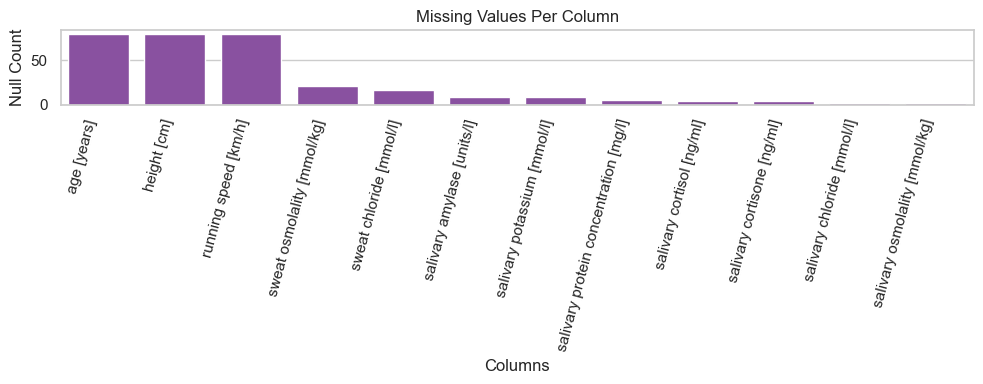

,id,age [years],height [cm],running speed [km/h],running interval,weight measured using Kern DE 150K2D [kg],weight measured using InBody 720 [kg],total body water using InBody 720 [l],impedance right arm at 1000kHz [Ohm],impedance left arm at 1000kHz [Ohm],...,sweat chloride [mmol/l],sweat osmolality [mmol/kg],salivary amylase [units/l],salivary chloride [mmol/l],salivary cortisol [ng/ml],salivary cortisone [ng/ml],salivary osmolality [mmol/kg],salivary potassium [mmol/l],salivary protein concentration [mg/l],dehydration_risk
0,1,29.0,190.0,8.0,0,85.515,85.90,54.0,231.27,232.63,...,NaN,NaN,NaN,28.0,NaN,NaN,76.0,NaN,576.8,Low
1,1,NaN,NaN,NaN,1,85.275,85.56,53.7,234.75,240.08,...,56.0,146.0,NaN,29.0,NaN,NaN,78.0,NaN,544.1,Low
2,1,NaN,NaN,NaN,2,84.895,85.32,54.0,230.81,233.95,...,55.0,134.0,111700.0,35.0,1.240,11.80,84.0,37.0,537.3,Low
3,1,NaN,NaN,NaN,3,84.540,84.90,54.0,231.96,236.32,...,53.0,123.0,NaN,38.0,0.947,10.60,95.0,38.0,595.6,Low
4,1,NaN,NaN,NaN,4,84.185,84.48,53.9,227.03,232.07,...,36.0,185.0,154110.0,37.0,0.727,9.64,91.0,32.0,541.3,Low


,id,age [years],height [cm],running speed [km/h],running interval,weight measured using Kern DE 150K2D [kg],weight measured using InBody 720 [kg],total body water using InBody 720 [l],impedance right arm at 1000kHz [Ohm],impedance left arm at 1000kHz [Ohm],...,sweat chloride [mmol/l],sweat osmolality [mmol/kg],salivary amylase [units/l],salivary chloride [mmol/l],salivary cortisol [ng/ml],salivary cortisone [ng/ml],salivary osmolality [mmol/kg],salivary potassium [mmol/l],salivary protein concentration [mg/l],dehydration_risk
87,10,NaN,NaN,NaN,6,54.302,54.64,36.4,220.09,215.22,...,51.0,160.0,777000.0,43.0,4.56,26.3,147.0,55.0,1269.2,Low
88,10,NaN,NaN,NaN,7,54.070,54.48,36.6,220.29,215.13,...,60.0,277.0,858310.0,40.0,7.43,29.6,146.0,55.0,1367.1,Medium
89,10,NaN,NaN,NaN,8,53.856,54.30,36.2,222.21,220.09,...,104.0,274.0,971550.0,57.0,7.03,36.3,194.0,64.0,2541.9,Medium


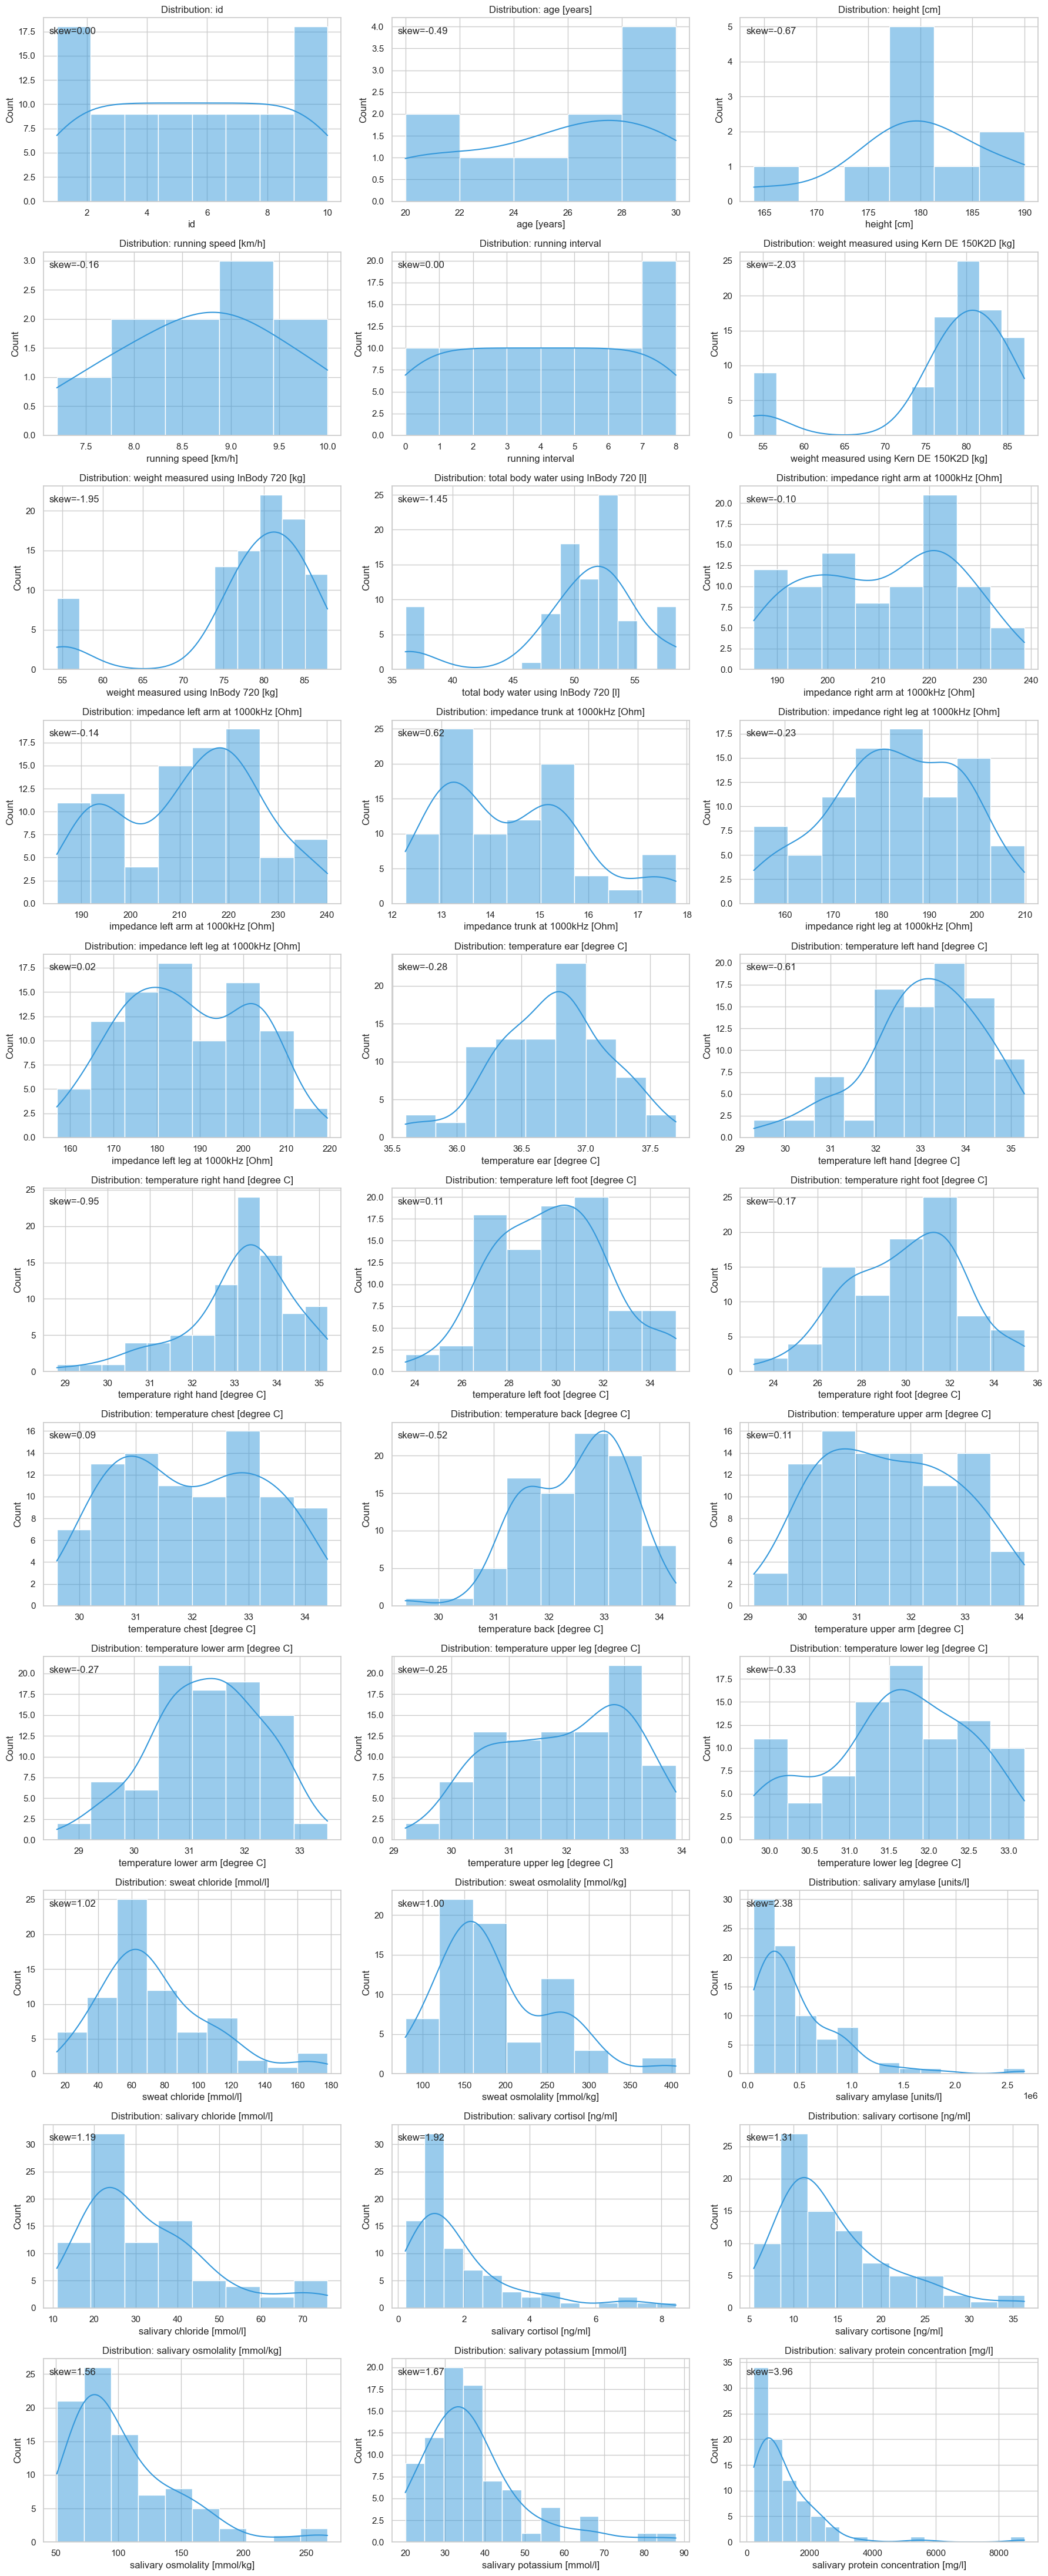

Skewness > threshold candidates: ['weight measured using Kern DE 150K2D [kg]', 'weight measured using InBody 720 [kg]', 'salivary amylase [units/l]', 'salivary cortisol [ng/ml]', 'salivary osmolality [mmol/kg]', 'salivary potassium [mmol/l]', 'salivary protein concentration [mg/l]']


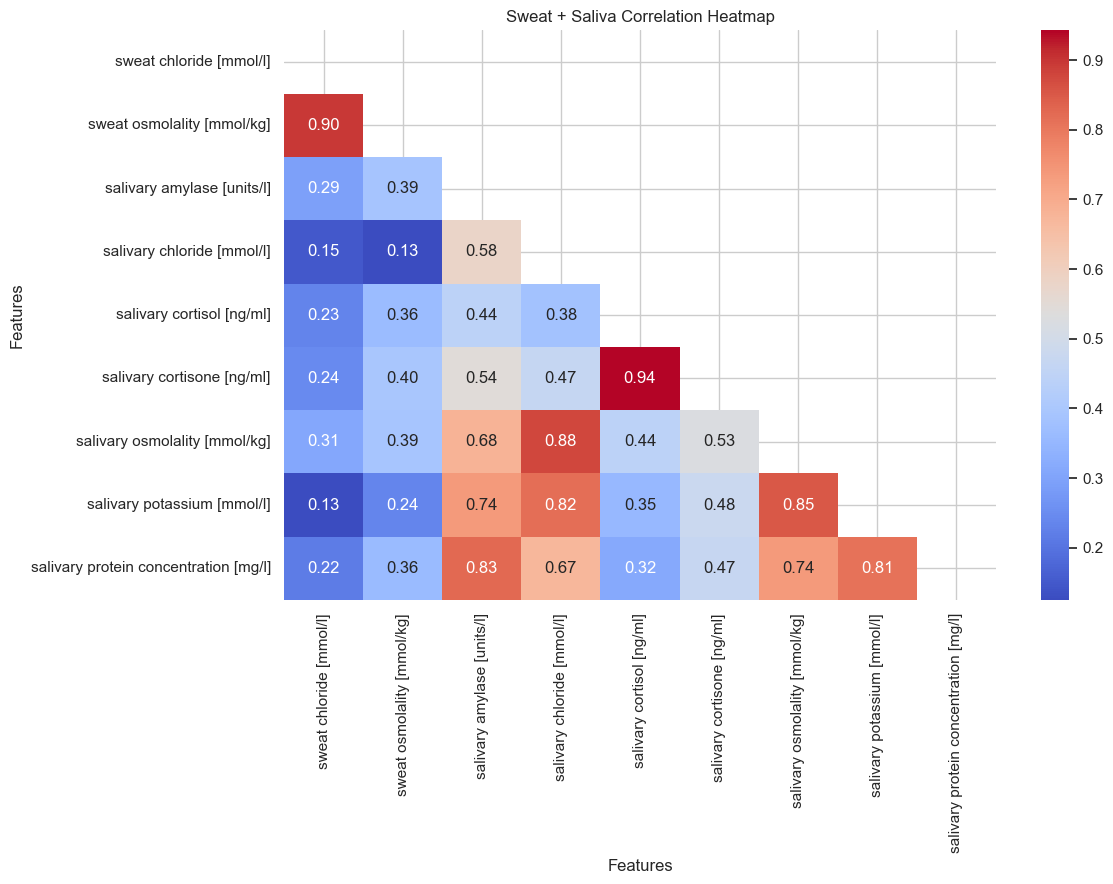

,feature_a,feature_b,r
0,salivary cortisol [ng/ml],salivary cortisone [ng/ml],0.942738
1,sweat chloride [mmol/l],sweat osmolality [mmol/kg],0.895130
2,salivary chloride [mmol/l],salivary osmolality [mmol/kg],0.878272
3,salivary osmolality [mmol/kg],salivary potassium [mmol/l],0.852960


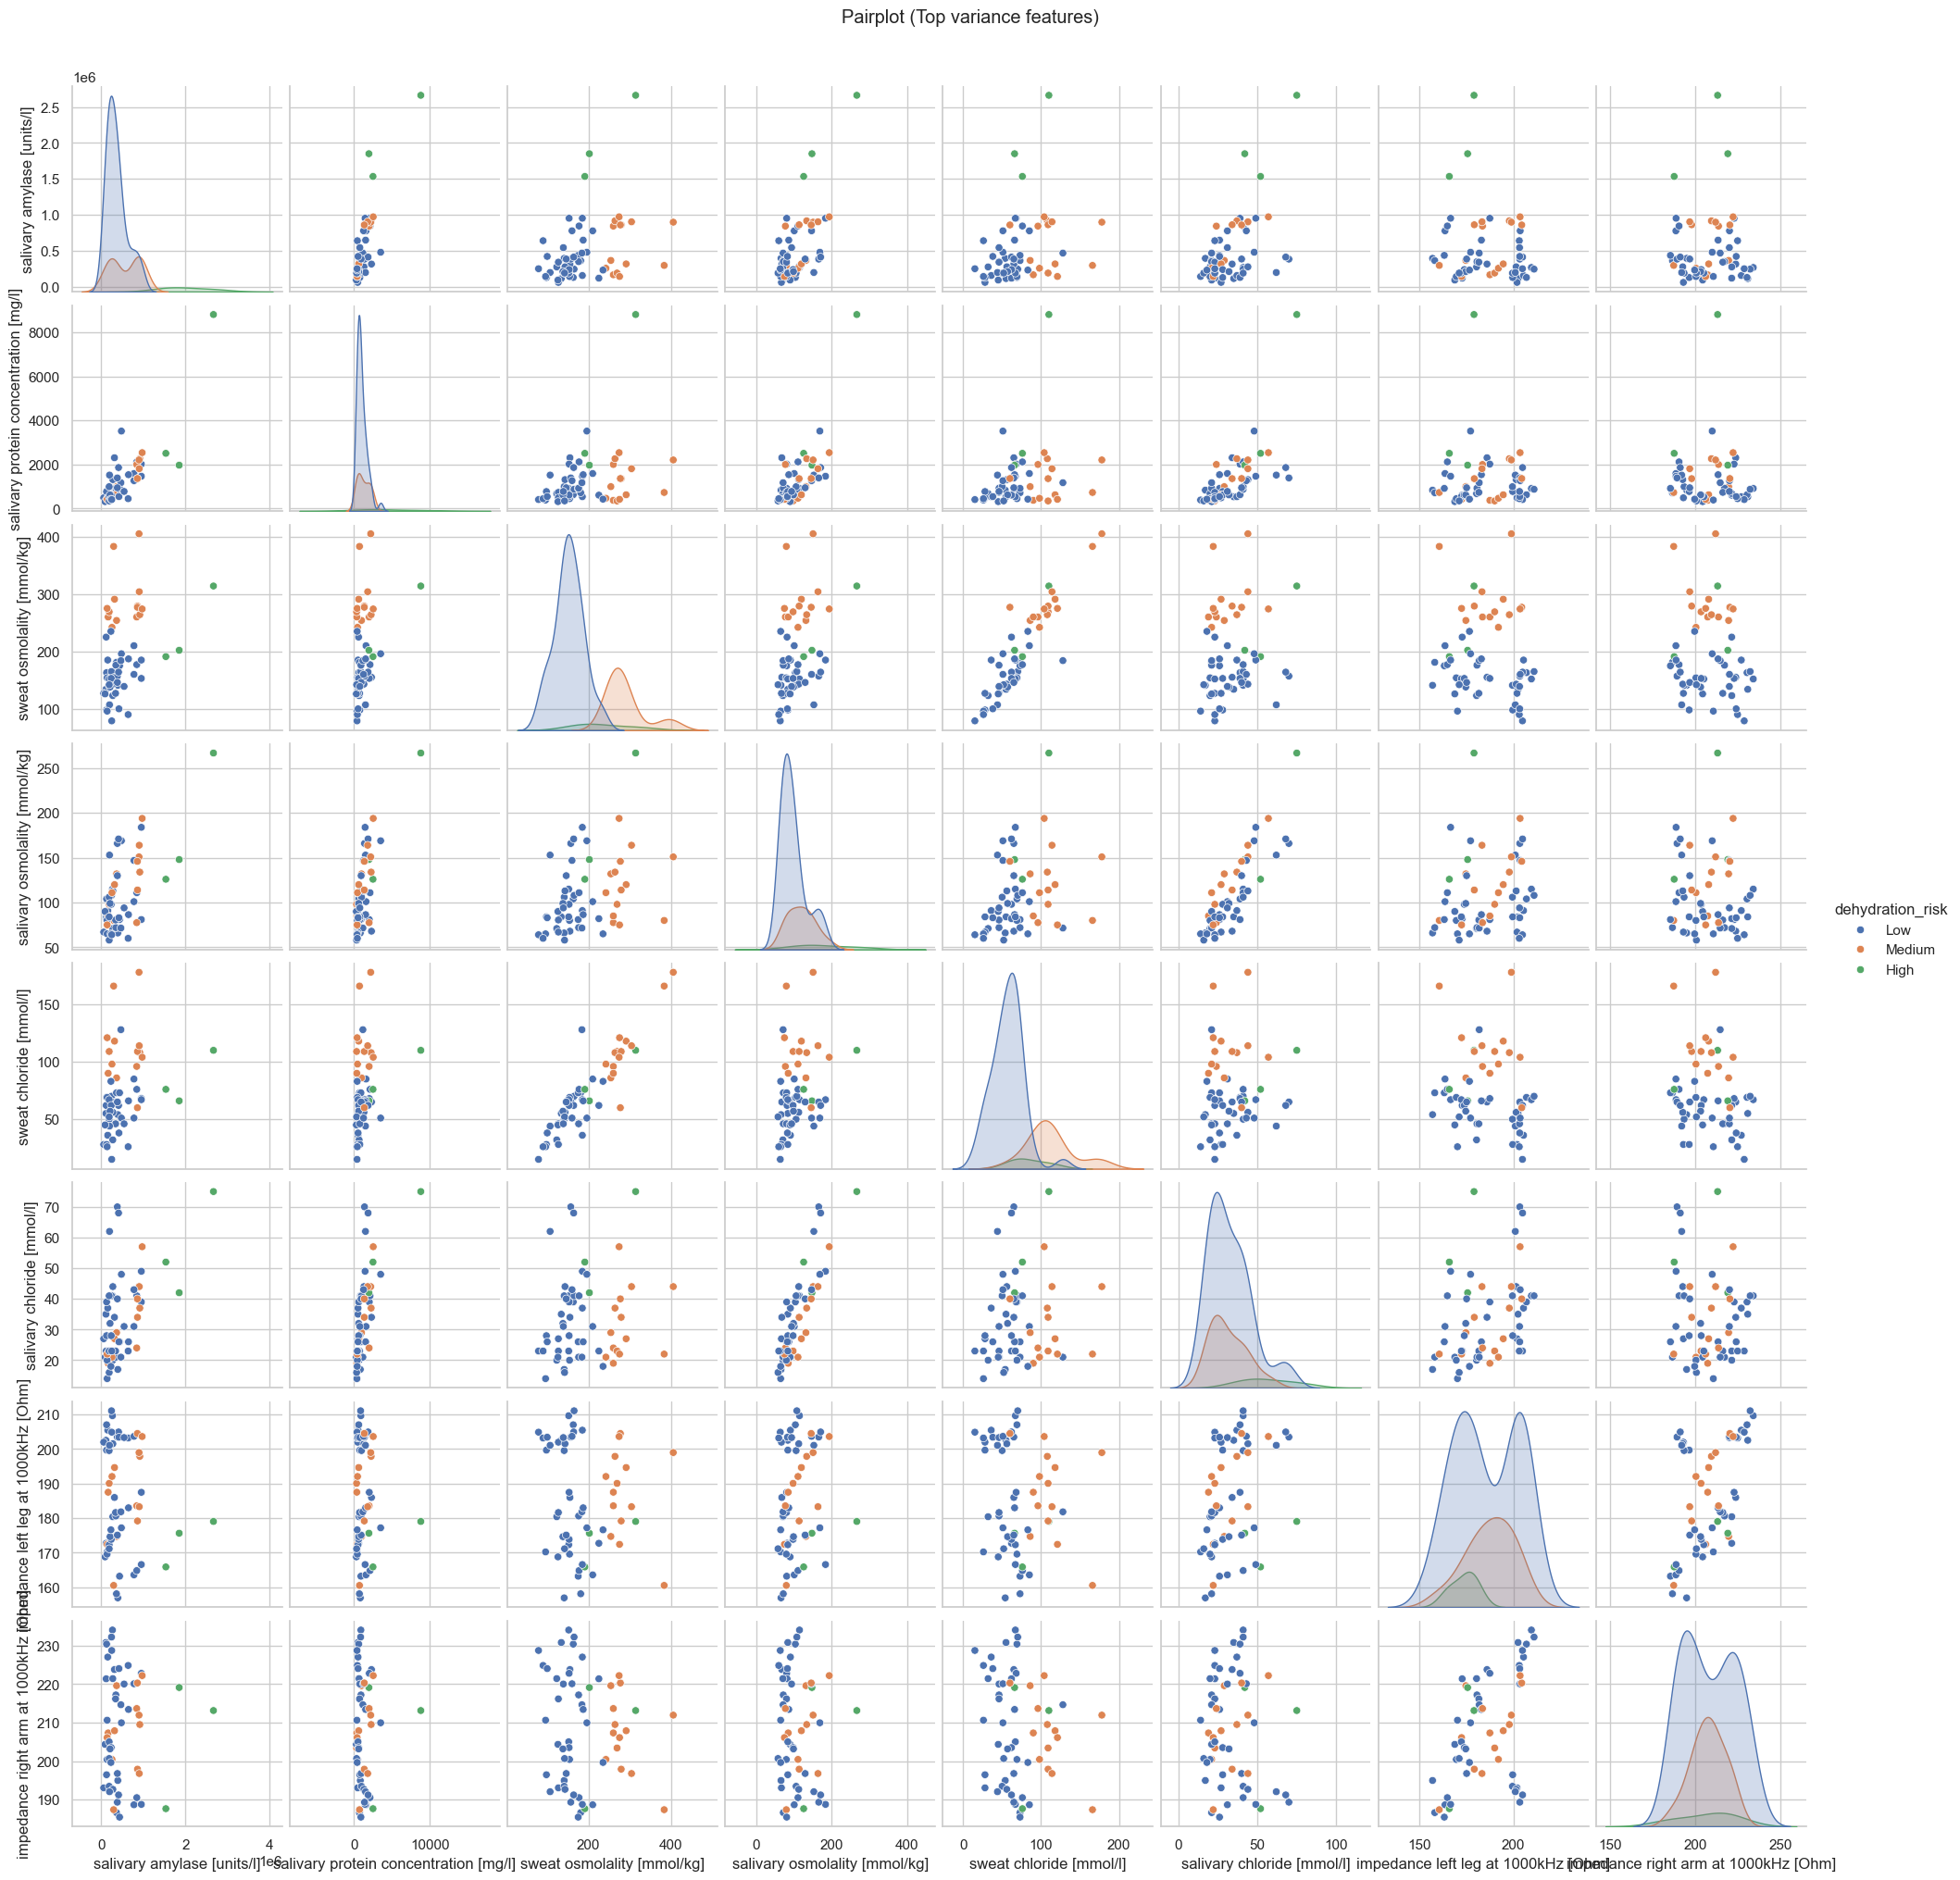

Top variance features used in pairplot: ['salivary amylase [units/l]', 'salivary protein concentration [mg/l]', 'sweat osmolality [mmol/kg]', 'salivary osmolality [mmol/kg]', 'sweat chloride [mmol/l]', 'salivary chloride [mmol/l]', 'impedance left leg at 1000kHz [Ohm]', 'impedance right arm at 1000kHz [Ohm]']


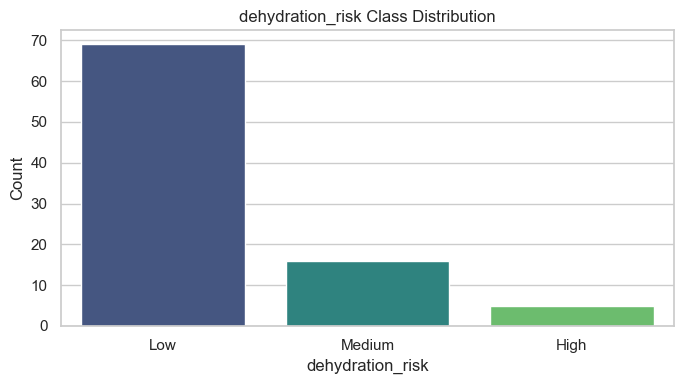

,id,age [years],height [cm],running speed [km/h],running interval,weight measured using Kern DE 150K2D [kg],weight measured using InBody 720 [kg],total body water using InBody 720 [l],impedance right arm at 1000kHz [Ohm],impedance left arm at 1000kHz [Ohm],...,temperature lower leg [degree C],sweat chloride [mmol/l],sweat osmolality [mmol/kg],salivary amylase [units/l],salivary chloride [mmol/l],salivary cortisol [ng/ml],salivary cortisone [ng/ml],salivary osmolality [mmol/kg],salivary potassium [mmol/l],salivary protein concentration [mg/l]
dehydration_risk,,,,,,,,,,,,,,,,,,,,,
High,4.800000,NaN,NaN,NaN,7.000000,79.264000,79.656000,49.540000,207.222000,208.720000,...,31.220000,97.800000,235.666667,1.740160e+06,62.20000,2.650400,20.060000,206.00000,66.600000,4277.140000
Low,5.275362,25.5,179.9,8.72,3.391304,78.339159,78.671304,50.937681,211.708696,212.488551,...,31.586957,62.314815,153.380000,3.403636e+05,30.61194,1.590600,13.294154,93.91791,34.241935,917.784615
Medium,6.687500,NaN,NaN,NaN,5.687500,76.782250,77.187500,48.975000,208.899375,209.967500,...,31.731250,111.600000,287.250000,5.911140e+05,32.56250,3.188187,19.135000,120.90625,38.059333,1326.086667


,feature,anova_p_value
22,sweat osmolality [mmol/kg],2.626896e-18
23,salivary amylase [units/l],9.576646e-17
29,salivary protein concentration [mg/l],2.710268e-11
27,salivary osmolality [mmol/kg],1.682079e-09
28,salivary potassium [mmol/l],1.038130e-08
21,sweat chloride [mmol/l],9.275554e-08
24,salivary chloride [mmol/l],1.417682e-05
1,running interval,8.633920e-05
26,salivary cortisone [ng/ml],7.239176e-04
25,salivary cortisol [ng/ml],2.078248e-03


In [3]:
## STEP 3: EDA EXECUTION
print("Shape:", df.shape)
print("\nInfo:")
df.info()
print("\nDescribe:")
display(df.describe(include="all").T)

missing = df.isnull().sum()
if (missing > 0).any():
    missing_nonzero = missing[missing > 0].sort_values(ascending=False)
    plt.figure(figsize=(10, 4))
    sns.barplot(x=missing_nonzero.index, y=missing_nonzero.values, color="#8e44ad")
    plt.title("Missing Values Per Column")
    plt.xlabel("Columns")
    plt.ylabel("Null Count")
    plt.xticks(rotation=75, ha="right")
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "main_missing_values.png", dpi=140, bbox_inches="tight")
    plt.show()

display(df.head(5))
display(df.tail(3))

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
skew_log_candidates = plot_per_column_distribution(
    df[numeric_cols],
    PLOT_DIR / "main_distributions.png",
    skew_threshold=SKEW_THRESHOLD,
)
print("Skewness > threshold candidates:", skew_log_candidates)

bio_cols = [
    c for c in numeric_cols
    if ("sweat" in c.lower() or "salivary" in c.lower()) and c != TARGET_COL
]
if len(bio_cols) >= 2:
    corr = plot_correlation_matrix(
        df,
        bio_cols,
        "Sweat + Saliva Correlation Heatmap",
        PLOT_DIR / "main_corr_sweat_saliva.png",
    )
    display(high_correlation_pairs(corr, thresh=HIGH_CORR_THRESHOLD))

pairplot_cols = plot_scatter_matrix(df, TARGET_COL, PAIRPLOT_TOP_K, PLOT_DIR / "main_pairplot.png")
print("Top variance features used in pairplot:", pairplot_cols)

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x=TARGET_COL, palette="viridis")
plt.title("dehydration_risk Class Distribution")
plt.xlabel(TARGET_COL)
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(PLOT_DIR / "main_target_countplot.png", dpi=140, bbox_inches="tight")
plt.show()

class_means = df.groupby(TARGET_COL)[[c for c in numeric_cols if c != TARGET_COL]].mean(numeric_only=True)
display(class_means)

anova_rows = []
for col in [c for c in numeric_cols if c != TARGET_COL]:
    groups = [g[col].dropna().values for _, g in df.groupby(TARGET_COL)]
    if all(len(arr) > 1 for arr in groups):
        _, p = f_oneway(*groups)
        anova_rows.append((col, float(p)))

anova_df = pd.DataFrame(anova_rows, columns=["feature", "anova_p_value"]).sort_values("anova_p_value")
display(anova_df)

In [4]:
## STEP 4: PREPROCESSING + PIPELINE FIT + ARTIFACT EXPORT
# inlined from models/preprocessing.py and models/dehydration_pipeline.py

def fit_iqr_bounds(frame: pd.DataFrame, cols: list[str], factor: float = 3.0) -> dict[str, tuple[float, float]]:
    bounds = {}
    for col in cols:
        s = pd.to_numeric(frame[col], errors="coerce").dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        bounds[col] = (float(q1 - factor * iqr), float(q3 + factor * iqr))
    return bounds


def apply_bounds(frame: pd.DataFrame, bounds: dict[str, tuple[float, float]]) -> pd.DataFrame:
    out = frame.copy()
    for col, (lo, hi) in bounds.items():
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce").clip(lo, hi)
    return out


def build_feature_weight_series(columns: list[str], key_terms: list[str]) -> pd.Series:
    w = pd.Series(1.0, index=columns)
    for c in columns:
        if any(k in c.lower() for k in key_terms):
            w.loc[c] = 0.5
    return w

work = df.copy()

medians = work.median(numeric_only=True)
work = work.fillna(medians)

winsor_cols = [c for c in work.columns if ("sweat" in c.lower() or "salivary" in c.lower()) and c != TARGET_COL]
bounds = fit_iqr_bounds(work, winsor_cols, factor=IQR_WINSOR_FACTOR)
work = apply_bounds(work, bounds)

for col in LOG1P_COLS:
    if col in work.columns:
        work[col] = np.log1p(pd.to_numeric(work[col], errors="coerce").clip(lower=0))

for col in ID_DROP_COLS:
    if col in work.columns:
        work = work.drop(columns=[col])

X = work.drop(columns=[TARGET_COL])
y_text = work[TARGET_COL].astype(str)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)

feature_weights = build_feature_weight_series(X.columns.tolist(), WEARABLE_SECONDARY_COL_KEYWORDS)
X_weighted = X.mul(feature_weights, axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X_weighted, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

numeric_features = X_train.columns.tolist()
preprocessor = ColumnTransformer(
    transformers=[
        ("imputer", SimpleImputer(strategy="median"), numeric_features),
    ],
    remainder="drop",
)

pipe_rf = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("scaler", RobustScaler()),
        ("clf", RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced", n_estimators=400)),
    ]
)

pipe_lr = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("scaler", RobustScaler()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", multi_class="auto")),
    ]
)

search_rf = GridSearchCV(pipe_rf, {"clf__max_depth": [None, 6, 10]}, cv=5, scoring="f1_macro", n_jobs=-1)
search_lr = GridSearchCV(pipe_lr, {"clf__C": [0.1, 1.0, 3.0]}, cv=5, scoring="f1_macro", n_jobs=-1)
search_rf.fit(X_train, y_train)
search_lr.fit(X_train, y_train)

best = search_rf if search_rf.best_score_ >= search_lr.best_score_ else search_lr
best_model = best.best_estimator_

pred = best_model.predict(X_test)
print(classification_report(y_test, pred, target_names=label_encoder.classes_))

main_model_path = ARTIFACT_DIR / "aquatrack_main_best_model.pkl"
main_median_path = ARTIFACT_DIR / "aquatrack_main_medians.pkl"
main_feature_path = ARTIFACT_DIR / "aquatrack_main_features.pkl"

joblib.dump(best_model, main_model_path)
joblib.dump(medians.to_dict(), main_median_path)
joblib.dump(X_train.columns.tolist(), main_feature_path)

for p in [main_model_path, main_median_path, main_feature_path]:
    loaded = joblib.load(p)
    if hasattr(loaded, "predict"):
        loaded.predict(X_test.iloc[:1])
    print(f"{p} ✓ validated")

TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'

# AquaTrack

## STEP 0: PROJECT HEADER
- **Purpose:** train and evaluate the main dehydration classification pipeline.
- **Dataset:** `aquatrack_labeled.csv`.
- **Module:** Main.
- **Inputs:** engineered feature frame and categorical target.
- **Outputs:** best fitted model artifact and prediction interface.

# AquaTrack — Full ML pipeline (dehydration risk)

End-to-end supervised learning on **`aquatrack_labeled.csv`**. The CSV stores the target as **`dehydration_level`**; we rename it to **`dehydration_risk`** here to match the study vocabulary.

**Contents:** minimal composites → train-only RF importance (top 15) → stratified 80/20 split → `Pipeline(RobustScaler, model)` with `GridSearchCV` (macro F1) → evaluation + CV → interpretability → `joblib` artifacts + **`predict_dehydration`**.

## STEP 1: IMPORTS AND PATHS
- Load libraries and configure deterministic constants.
- **Inputs:** repository root and module imports.
- **Outputs:** configured runtime, constants, and paths.

In [ ]:
from __future__ import annotations

import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, RobustScaler

# Project root (same pattern as other AquaTrack notebooks)
ROOT = Path.cwd().resolve()
if not (ROOT / "models").is_dir():
    ROOT = ROOT.parent
if not (ROOT / "aquatrack_labeled.csv").is_file():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Legacy package import removed; inline pipeline utilities are defined above.

DATA_PATH = ROOT / "aquatrack_labeled.csv"
MODEL_DIR = ROOT / "models" / "artifacts"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.2
N_TOP_FEATURES = 15
CV_FOLDS = 10


def log_shape(name: str, value) -> None:
    """Print a compact shape summary."""
    print(f"{name}: {getattr(value, 'shape', None)}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

print("ROOT:", ROOT)
print("Data:", DATA_PATH.exists(), DATA_PATH)

ROOT: /Users/divyabelumana/Desktop/AquaTrack
Data: True /Users/divyabelumana/Desktop/AquaTrack/aquatrack_labeled.csv


## STEP 2: LOAD DATA AND TARGET
- Read labeled training dataset and target column.
- **Inputs:** `aquatrack_labeled.csv`.
- **Outputs:** dataframe `df` and target metadata.

Map **`dehydration_level` → `dehydration_risk`** so naming matches the requested target column.

In [ ]:
df = pd.read_csv(DATA_PATH)
if "dehydration_level" in df.columns:
    df = df.rename(columns={"dehydration_level": "dehydration_risk"})

TARGET = "dehydration_risk"
assert TARGET in df.columns, f"Missing target column; got: {df.columns.tolist()}"

df[TARGET] = df[TARGET].astype(str).str.strip()
allowed = {"Low", "Medium", "High"}
bad = set(df[TARGET].unique()) - allowed
if bad:
    raise ValueError(f"Unexpected target labels: {bad}")

print(df.shape)
display(df[TARGET].value_counts())
df.head(3)

(90, 34)


dehydration_risk
Low       69
Medium    16
High       5
Name: count, dtype: int64

,id,age [years],height [cm],running speed [km/h],running interval,weight measured using Kern DE 150K2D [kg],weight measured using InBody 720 [kg],total body water using InBody 720 [l],impedance right arm at 1000kHz [Ohm],impedance left arm at 1000kHz [Ohm],...,sweat chloride [mmol/l],sweat osmolality [mmol/kg],salivary amylase [units/l],salivary chloride [mmol/l],salivary cortisol [ng/ml],salivary cortisone [ng/ml],salivary osmolality [mmol/kg],salivary potassium [mmol/l],salivary protein concentration [mg/l],dehydration_risk
0,1,29.0,190.0,8.0,0,85.515,85.90,54.0,231.27,232.63,...,NaN,NaN,NaN,28.0,NaN,NaN,76.0,NaN,576.8,Low
1,1,NaN,NaN,NaN,1,85.275,85.56,53.7,234.75,240.08,...,56.0,146.0,NaN,29.0,NaN,NaN,78.0,NaN,544.1,Low
2,1,NaN,NaN,NaN,2,84.895,85.32,54.0,230.81,233.95,...,55.0,134.0,111700.0,35.0,1.24,11.8,84.0,37.0,537.3,Low


## 3. Feature engineering (minimal composites)

Implementation lives in **`models/dehydration_pipeline.py`** so `joblib.load()` can unpickle **`DehydrationArtifact`** in a fresh Python session (same `sys.path` to the repo root).

- **Sweat composite:** sweat chloride + sweat osmolality  
- **Saliva composite:** salivary osmolality + salivary chloride  
- **Exertion load:** running speed × running interval  
- **Hydration ratio:** total body water (L) / InBody weight (kg)  
- **Drop** the eight source columns above once composites exist.

`id` is excluded from modeling features (identifier only).

In [ ]:
# engineer_features, ID_COL, COMPOSITE_COLS imported from models.dehydration_pipeline (joblib-safe)

# Quick sanity check on full table (before split)
_probe = engineer_features(df.drop(columns=[TARGET]))
print("Engineered shape (no target):", _probe.shape)
print("New columns:", [c for c in COMPOSITE_COLS if c in _probe.columns])

Engineered shape (no target): (90, 29)
New columns: ['sweat_composite', 'saliva_composite', 'exertion_load', 'hydration_ratio']


## STEP 4: TRAIN TEST SPLIT
- Create stratified train/test partitions.
- **Inputs:** engineered features and categorical target.
- **Outputs:** `X_train_src`, `X_test_src`, `y_train`, `y_test`.

Split **before** feature selection so importances are computed **only on training** rows (no leakage).

In [ ]:
feature_source = df.drop(columns=[TARGET]).copy()
if ID_COL in feature_source.columns:
    feature_source = feature_source.drop(columns=[ID_COL])

y = df[TARGET].values

X_train_src, X_test_src, y_train, y_test = train_test_split(
    feature_source,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

log_shape("Train", X_train_src)
log_shape("Test", X_test_src)
print(f"Train class counts: {pd.Series(y_train).value_counts().to_dict()}")

Train: (72, 32) Test: (18, 32)
Train class counts: {'Low': 55, 'Medium': 13, 'High': 4}


## 5. Median imputation (train statistics only)

We store **raw** medians (pre-composite) for filling missing keys in `predict_dehydration`, then re-engineer. We also store **engineered** medians for any remaining NaNs after composites.

In [ ]:
BASE_FEATURE_COLS = list(X_train_src.columns)

train_medians_raw = X_train_src.median(numeric_only=True)

X_train_eng = engineer_features(X_train_src)
X_test_eng = engineer_features(X_test_src)

train_medians_eng = X_train_eng.median(numeric_only=True)

X_train_eng = X_train_eng.fillna(train_medians_eng)
X_test_eng = X_test_eng.fillna(train_medians_eng)

print("Engineered train:", X_train_eng.shape)
X_train_eng.isna().sum().sum(), X_test_eng.isna().sum().sum()

Engineered train: (72, 28)


(np.int64(0), np.int64(0))

## 6. Feature selection — Random Forest importance (top 15, train only)

A fast RF on the **training** engineered matrix ranks features; we keep the **top 15** for all downstream models.

In [ ]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

rf_sel = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_sel.fit(X_train_eng, y_train_enc)

importances = pd.Series(rf_sel.feature_importances_, index=X_train_eng.columns).sort_values(
    ascending=False
)
selected_features = importances.head(N_TOP_FEATURES).index.tolist()

print("Top 15 features:")
display(importances.head(N_TOP_FEATURES))

X_train = X_train_eng[selected_features].copy()
X_test = X_test_eng[selected_features].copy()

Top 15 features:


sweat_composite                              0.199129
salivary amylase [units/l]                   0.150706
salivary protein concentration [mg/l]        0.068643
saliva_composite                             0.066690
salivary potassium [mmol/l]                  0.061214
salivary cortisone [ng/ml]                   0.039608
impedance left leg at 1000kHz [Ohm]          0.034470
hydration_ratio                              0.032140
temperature upper leg [degree C]             0.031504
temperature right hand [degree C]            0.029852
impedance trunk at 1000kHz [Ohm]             0.025702
weight measured using Kern DE 150K2D [kg]    0.025497
temperature left foot [degree C]             0.024350
impedance left arm at 1000kHz [Ohm]          0.023451
temperature lower arm [degree C]             0.022354
dtype: float64

## STEP 7: MODEL TRAINING
- Fit LogisticRegression and RandomForest with `Pipeline` + `GridSearchCV`.
- **Inputs:** selected train features and encoded labels.
- **Outputs:** tuned estimators and CV scores.

**Note:** With only **~90 rows** and **5 High** labels, stratified 5-fold CV may warn that the smallest class has fewer than five members; metrics are still computed but should be read cautiously.

- **`Pipeline([('scaler', RobustScaler()), ('clf', model)])`** keeps scaling inside CV folds (no leakage).  
- **`class_weight='balanced'`** for both classifiers.  
- **`scoring='f1_macro'`**, **`cv=5`**, stratified folds.

In [ ]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

pipe_lr = Pipeline(
    [
        ("scaler", RobustScaler()),
        (
            "clf",
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                random_state=RANDOM_STATE,
                solver="lbfgs",
            ),
        ),
    ]
)

param_grid_lr = {
    "clf__C": [0.01, 0.1, 1.0, 10.0],
}

grid_lr = GridSearchCV(
    pipe_lr,
    param_grid_lr,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    refit=True,
)
grid_lr.fit(X_train, y_train_enc)
print("LogisticRegression best params:", grid_lr.best_params_)
print("Best CV macro F1 (train):", round(grid_lr.best_score_, 4))

/Users/divyabelumana/Desktop/AquaTrack/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


LogisticRegression best params: {'clf__C': 10.0}
Best CV macro F1 (train): 0.9622


In [ ]:
pipe_rf = Pipeline(
    [
        ("scaler", RobustScaler()),
        (
            "clf",
            RandomForestClassifier(
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

param_grid_rf = {
    "clf__n_estimators": [200, 400],
    "clf__max_depth": [None, 8, 16],
    "clf__min_samples_leaf": [1, 2],
}

grid_rf = GridSearchCV(
    pipe_rf,
    param_grid_rf,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    refit=True,
)
grid_rf.fit(X_train, y_train_enc)
print("RandomForest best params:", grid_rf.best_params_)
print("Best CV macro F1 (train):", round(grid_rf.best_score_, 4))

/Users/divyabelumana/Desktop/AquaTrack/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


RandomForest best params: {'clf__max_depth': None, 'clf__min_samples_leaf': 2, 'clf__n_estimators': 200}
Best CV macro F1 (train): 0.8396


## 8. Evaluation — hold-out test + 5-fold CV on training

We report **accuracy**, **macro F1**, full **classification report**, and a **confusion matrix** heatmap for each tuned model. **5-fold CV macro F1** on the training matrix quantifies stability; the **test set** estimates generalization on held-out 20%.

LogisticRegression (Pipeline + RobustScaler)
5-fold CV macro F1 (train): [1.     0.9365 1.     1.     0.8744] mean: 0.9622
Hold-out accuracy: 1.0 | macro F1: 1.0
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         1
         Low       1.00      1.00      1.00        14
      Medium       1.00      1.00      1.00         3

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



/Users/divyabelumana/Desktop/AquaTrack/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


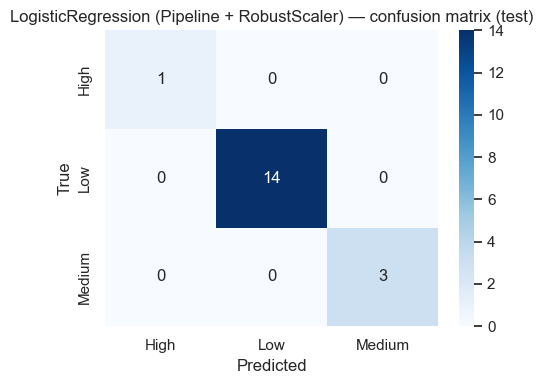

/Users/divyabelumana/Desktop/AquaTrack/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


RandomForest (Pipeline + RobustScaler)
5-fold CV macro F1 (train): [0.5722 0.873  0.8783 1.     0.8744] mean: 0.8396
Hold-out accuracy: 1.0 | macro F1: 1.0
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         1
         Low       1.00      1.00      1.00        14
      Medium       1.00      1.00      1.00         3

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



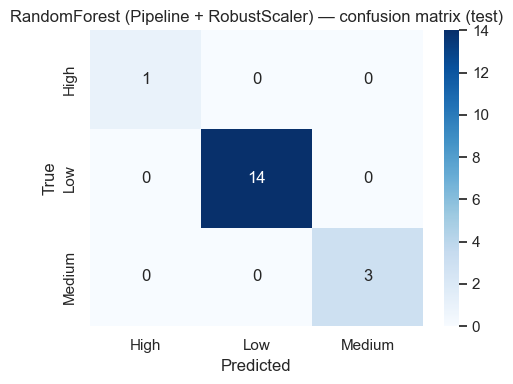

In [ ]:
def evaluate_split(name: str, model, X_tr, y_tr_e, X_te, y_te_e, le: LabelEncoder):
    """Test metrics + 5-fold CV macro F1 on training data."""
    cv_scores = cross_val_score(model, X_tr, y_tr_e, cv=cv, scoring="f1_macro", n_jobs=-1)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te_e, y_pred)
    f1m = f1_score(y_te_e, y_pred, average="macro")
    print("=" * 72)
    print(name)
    print("5-fold CV macro F1 (train):", np.round(cv_scores, 4), "mean:", round(cv_scores.mean(), 4))
    print("Hold-out accuracy:", round(acc, 4), "| macro F1:", round(f1m, 4))
    print(classification_report(y_te_e, y_pred, target_names=le.classes_))
    cm = confusion_matrix(y_te_e, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=le.classes_,
        yticklabels=le.classes_,
        ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{name} — confusion matrix (test)")
    plt.tight_layout()
    plt.show()
    return {"cv_f1_macro_mean": cv_scores.mean(), "accuracy": acc, "f1_macro": f1m}


metrics_lr = evaluate_split(
    "LogisticRegression (Pipeline + RobustScaler)",
    grid_lr.best_estimator_,
    X_train,
    y_train_enc,
    X_test,
    y_test_enc,
    le,
)
metrics_rf = evaluate_split(
    "RandomForest (Pipeline + RobustScaler)",
    grid_rf.best_estimator_,
    X_train,
    y_train_enc,
    X_test,
    y_test_enc,
    le,
)

In [ ]:
# Side-by-side comparison (CV mean on train + hold-out test)
compare = pd.DataFrame(
    {
        "LogisticRegression": metrics_lr,
        "RandomForest": metrics_rf,
    }
).T
compare = compare[["cv_f1_macro_mean", "accuracy", "f1_macro"]]
display(compare.round(4))

# Pick best by hold-out macro F1; break ties with higher CV macro F1 on training folds
if metrics_lr["f1_macro"] > metrics_rf["f1_macro"]:
    best_name, best_pipeline = "LogisticRegression", grid_lr.best_estimator_
elif metrics_rf["f1_macro"] > metrics_lr["f1_macro"]:
    best_name, best_pipeline = "RandomForest", grid_rf.best_estimator_
else:
    if metrics_lr["cv_f1_macro_mean"] >= metrics_rf["cv_f1_macro_mean"]:
        best_name, best_pipeline = "LogisticRegression", grid_lr.best_estimator_
    else:
        best_name, best_pipeline = "RandomForest", grid_rf.best_estimator_
    print("Tie on test macro F1 — broke tie using mean CV macro F1.")
print("Best model:", best_name)

,cv_f1_macro_mean,accuracy,f1_macro
LogisticRegression,0.9622,1.0,1.0
RandomForest,0.8396,1.0,1.0


Tie on test macro F1 — broke tie using mean CV macro F1.
Best model: LogisticRegression


## 9. Interpretability

- **Random Forest:** bar chart of importances on the **tuned** forest (top 5 highlighted).  
- **Logistic Regression:** coefficient heatmap **per class** vs feature (multinomial).

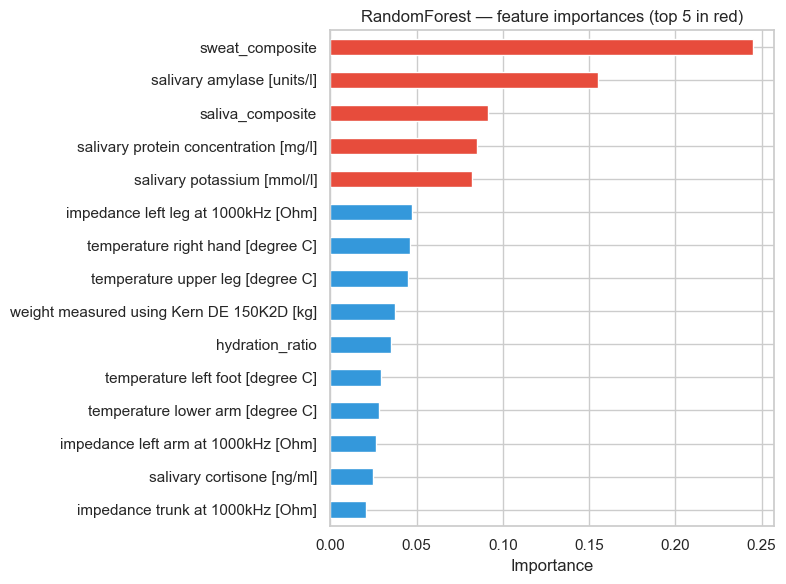

In [ ]:
# --- Random Forest feature importance (top 5 highlighted) ---
rf_model = grid_rf.best_estimator_.named_steps["clf"]
imp = pd.Series(rf_model.feature_importances_, index=selected_features).sort_values(ascending=True)
colors = ["#e74c3c" if feat in imp.tail(5).index else "#3498db" for feat in imp.index]
fig, ax = plt.subplots(figsize=(8, 6))
imp.plot(kind="barh", ax=ax, color=colors)
ax.set_title("RandomForest — feature importances (top 5 in red)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

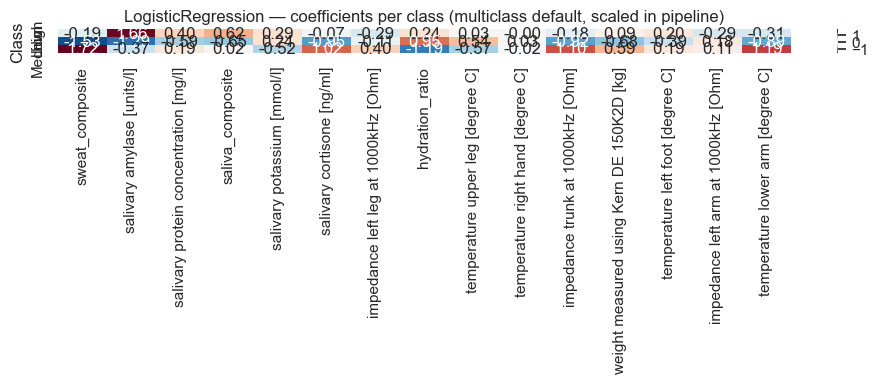

In [ ]:
# --- Logistic Regression coefficients per class ---
lr_model = grid_lr.best_estimator_.named_steps["clf"]
coef = pd.DataFrame(lr_model.coef_, columns=selected_features, index=le.classes_)
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(coef, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("LogisticRegression — coefficients per class (multiclass default, scaled in pipeline)")
ax.set_ylabel("Class")
plt.tight_layout()
plt.show()

## 10. Prediction API — `predict_dehydration(input_dict)`

Keys should match **original CSV column names** (before composites). Missing keys are filled from **`train_medians_raw`**, then the same engineering + column subset + **`best_pipeline`** run as in training.

In [ ]:
artifact = DehydrationArtifact(
    best_pipeline=best_pipeline,
    pipeline_lr=grid_lr.best_estimator_,
    pipeline_rf=grid_rf.best_estimator_,
    best_model_name=best_name,
    label_encoder=le,
    train_medians_raw=train_medians_raw,
    train_medians_eng=train_medians_eng,
    base_feature_cols=BASE_FEATURE_COLS,
    selected_features=selected_features,
    target_col=TARGET,
)


def predict_dehydration(input_dict: dict) -> str:
    """Return 'Low', 'Medium', or 'High' using the trained best pipeline."""
    return artifact.predict_dehydration(input_dict)


# Smoke test: first training row reconstructed from raw features
_sample = X_train_src.iloc[0].to_dict()
print("Smoke prediction:", predict_dehydration(_sample))
print("Actual label:", y_train[0])

Smoke prediction: Low
Actual label: Low


## STEP 11: SAVE ARTIFACT
- Persist only the final best main-model artifact in `models/artifacts`.
- **Inputs:** fitted `DehydrationArtifact` and one raw sample row.
- **Outputs:** `aquatrack_main_classifier.pkl` with reload validation.

In [ ]:
artifact_path = MODEL_DIR / "aquatrack_main_classifier.pkl"
joblib.dump(artifact, artifact_path)
print(f"Saved: {artifact_path}")

# Reload validation: one predict pass and output shape check.
loaded_artifact = joblib.load(artifact_path)
loaded_pred = loaded_artifact.predict_dehydration(_sample)
assert loaded_pred == predict_dehydration(_sample)
print(f"Reload validation prediction: {loaded_pred}")
print(f"Validation output shape: {(1,)}")

Saved: /Users/divyabelumana/Desktop/AquaTrack/models/saved/dehydration_artifact.joblib
Saved: /Users/divyabelumana/Desktop/AquaTrack/models/saved/dehydration_bundle_dict.joblib
